# Gaza Health Ministry named casualty lists — age and sex distribution

This notebook computes every number and every chart in the essay
[*Not Indiscriminate: What Hamas's Own Numbers Show*](../posts/gaza-casualty-demographics.html).

**The question.** If deaths in Gaza were indiscriminate with respect to age and sex — if the
thing that killed people did not care who was underneath it — then the dead would be
approximately a random sample of the living, and a random sample resembles the population it
was drawn from. That is a testable claim. This notebook tests it.

**The inputs.**

| | |
|---|---|
| **Numerator** | The Gaza Ministry of Health's own published lists of named dead, ten CSV files covering January 2024 to July 2025, archived at [gazadeaths.org](https://www.gazadeaths.org/en/sources). Each row is one person: national ID, name, date of birth, age, sex. |
| **Denominator** | Gaza Strip population by five-year age band and sex, [PCBS](https://www.pcbs.gov.ps/) figures for reference year 2023, published as the OCHA/UNFPA Common Operational Dataset [`cod-ps-pse`](https://data.humdata.org/dataset/cod-ps-pse). This is a pre-war baseline, which is what the test needs. |

**Reproducing this.** The Ministry lists are not redistributed in this repository — download them
from gazadeaths.org into a folder named `gaza data/` beside this one. The population baseline
*is* in the repository, at `data/pse_admpop_adm1_2023.csv`, because it is small and public.

Nothing below is estimated, smoothed, or imputed. Where a record cannot be used it is dropped
and counted, and the count is printed.

In [1]:
import hashlib, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import chisquare

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

HERE     = Path.cwd()
RAW      = HERE.parent / "gaza data"      # the MoH lists (not in the repo)
POP_CSV  = HERE / "data" / "pse_admpop_adm1_2023.csv"
OUT_JS   = HERE.parent / "assets" / "gaza-data.js"

# --- the site's palette, so the notebook and the published charts agree -------
GREY   = "#BAB0AC"   # the population baseline: context, not a category
GREY_L = "#D9D9D9"
RED    = "#E15759"   # the dead: the one highlighted series
BLUE   = "#4E79A7"
INK    = "#333333"
MUTED  = "#767676"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.edgecolor": "#DDDDDD", "axes.labelcolor": MUTED, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": MUTED, "ytick.labelcolor": MUTED,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 8.5,
})

# Paths are printed relative to the repository root: this notebook is
# published as HTML, and nobody needs my home directory.
rel = lambda p: p.relative_to(HERE.parent)
print(f"raw lists folder : {rel(RAW)}/  -- {'found' if RAW.is_dir() else 'MISSING'}")
print(f"population file  : {rel(POP_CSV)} -- {'found' if POP_CSV.is_file() else 'MISSING'}")

raw lists folder : gaza data/  -- found
population file  : analysis/data/pse_admpop_adm1_2023.csv -- found


## 1. Inventory the lists

Ten files were downloaded. The first thing to check is whether they are ten *lists* — two of
them could be the same export saved twice. Hashing the bytes settles it rather than trusting
the filenames.

In [2]:
files = sorted(RAW.glob("*.csv"))
rows, seen, lists = [], {}, []

for f in files:
    digest = hashlib.md5(f.read_bytes()).hexdigest()
    date   = re.match(r"MoH-(\d{4}-\d{2}-\d{2})", f.name).group(1)
    dup_of = seen.get(digest)
    rows.append({"file": f.name[:34] + "…", "list date": date,
                 "md5": digest[:8], "duplicate of": dup_of or ""})
    if dup_of:
        continue
    seen[digest] = date
    df = pd.read_csv(f, dtype=str, keep_default_na=False)
    lists.append((date, df))

inventory = pd.DataFrame(rows)
display(inventory)
print(f"\n{len(files)} files → {len(lists)} distinct lists "
      f"({len(files) - len(lists)} byte-identical duplicate).")

,file,list date,md5,duplicate of
0,MoH-2024-01-05-rNQ2cecvsbOdzGN3EDf…,2024-01-05,ca7aba64,
1,MoH-2024-03-29-tE8GTpcNl0sHnjN5Ygj…,2024-03-29,f751d170,
2,MoH-2024-04-30_edited-FQ20GX6KVBCL…,2024-04-30,36a8b7c4,
3,MoH-2024-04-30_edited-SFkYs2t6xSEs…,2024-04-30,36a8b7c4,2024-04-30
4,MoH-2024-06-30_edited-FeGee1fcc1Jn…,2024-06-30,1aaf9328,
5,MoH-2024-08-31_edited-VJwKINol6A9q…,2024-08-31,5408ba2c,
6,MoH-2025-03-23-NehFnLUa47bE42mkFsk…,2025-03-23,cc28a438,
7,MoH-2025-06-15-K6mJgX3PJ1iZTWB8hJB…,2025-06-15,caeea485,
8,MoH-2025-07-15-OR0Ge1rNshayOYuiQ9N…,2025-07-15,b6f6d4f6,
9,MoH-2025-07-31-koX2irOztUhD4wldRZd…,2025-07-31,2d1cf608,



10 files → 9 distinct lists (1 byte-identical duplicate).


Ten files, nine lists: the two `2024-04-30` exports are byte-for-byte identical. Everything
from here on uses the nine distinct lists. The essay says "nine lists" for that reason.

## 2. What the columns actually mean

The schema drifts across releases — early lists have no `age` column at all, and the later
ones rename `sex` values from `M`/`F` to `m`/`f`. More importantly, there are two things
`age` could mean, and they give different answers:

- **age at the list date** — would grow as later lists are published, or
- **age at death** — would be frozen once the person is recorded.

We can tell which, because the lists share national ID numbers. Take every person who appears
in both the March 2025 and July 2025 lists and check whether their recorded age moved.

In [3]:
for date, df in lists:
    print(f"{date}  n={len(df):>6,}  columns: {', '.join(df.columns)}")

a = dict(lists)["2025-03-23"]
b = dict(lists)["2025-07-31"]
m = a[["id", "age", "dob", "sex"]].merge(b[["id", "age", "dob", "sex"]],
                                         on="id", suffixes=("_mar", "_jul"))
print(f"\n{len(m):,} people appear in both the 2025-03-23 and 2025-07-31 lists.")
for col in ("age", "dob", "sex"):
    same = (m[f"{col}_mar"].str.lower() == m[f"{col}_jul"].str.lower()).mean()
    print(f"  {col:4s} unchanged between the two lists: {same*100:6.2f}%")

2024-01-05  n=14,140  columns: id, name_ar_raw, dob, sex
2024-03-29  n=20,390  columns: id, name_ar_raw, dob, age, sex, source
2024-04-30  n=24,669  columns: id, name_ar_raw, dob, age, sex, source
2024-06-30  n=28,173  columns: index, name_ar_raw, id, dob, sex, age, source
2024-08-31  n=34,306  columns: index, name_ar_raw, id, dob, sex, age, source
2025-03-23  n=50,020  columns: index, name_en, name_ar_raw, age, dob, sex, id, source
2025-06-15  n=55,202  columns: index, name_en, name_ar_raw, age, dob, sex, id, source
2025-07-15  n=58,380  columns: index, name_en, name_ar_raw, age, dob, sex, id, source
2025-07-31  n=60,199  columns: index, name_en, name_ar_raw, age, dob, sex, id, source

49,947 people appear in both the 2025-03-23 and 2025-07-31 lists.
  age  unchanged between the two lists:  99.72%
  dob  unchanged between the two lists:  99.99%
  sex  unchanged between the two lists: 100.00%


`age` is frozen (99.7% unchanged over four months in which everyone alive would have aged),
while `dob` and `sex` are essentially stable too. So **`age` is age at death**, not age at
publication — which is the field this analysis wants. The 0.3% that move are ordinary record
revisions.

Confirming it from the other direction: adding `age` years to `dob` should land on roughly the
date of death, and it does — the implied dates cluster through the war, not at the list date.

In [4]:
latest_date, latest = lists[-1]
implied = pd.to_datetime(latest["dob"]) + pd.to_timedelta(
    pd.to_numeric(latest["age"]) * 365.2425, unit="D")
print(f"list published {latest_date}; dob + age implies a date of:")
print(implied.quantile([.05, .25, .5, .75, .95]).dt.date.to_string())

list published 2025-07-31; dob + age implies a date of:
0.05    2022-12-23
0.25    2023-05-07
0.50    2023-09-28
0.75    2024-04-15
0.95    2025-01-26


Median implied date late September 2023 — i.e. these are birthdays rounded around dates of
death spread across the war, which is what age-at-death looks like. If `age` were age at
publication every implied date would sit on 2025-07-31.

## 3. Cleaning rule, stated once and applied everywhere

A record is **usable** if it has a parseable age between 0 and 120 and a sex of `m` or `f`.
Anything else is dropped and counted. For the one list with no `age` column (2024-01-05), age
is derived from date of birth as of the list date; that list is marked and is never mixed with
the others.

The lists also carry a visible artefact: a placeholder date of birth of `1990-01-01`. It is
worth counting rather than ignoring.

In [5]:
BANDS = ["0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34",
         "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65+"]
EDGES = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]


def clean(date, df):
    # -> (usable rows with age + sex, number excluded, how age was obtained)
    sex = df["sex"].str.strip().str.lower()
    if "age" in df.columns:
        age, how = pd.to_numeric(df["age"], errors="coerce"), "age column"
    else:
        dob = pd.to_datetime(df["dob"], errors="coerce")
        age = np.floor((pd.Timestamp(date) - dob).dt.days / 365.2425)
        how = "derived from dob"
    ok = age.notna() & age.between(0, 120) & sex.isin(["m", "f"])
    out = pd.DataFrame({"id": df["id"], "age": age[ok], "sex": sex[ok]}).dropna(subset=["age"])
    out["band"] = pd.cut(out["age"], bins=EDGES, right=False, labels=BANDS)
    return out, int((~ok).sum()), how


quality = []
clean_lists = []
for date, df in lists:
    c, excluded, how = clean(date, df)
    clean_lists.append((date, c))
    quality.append({"list": date, "records": len(df), "usable": len(c),
                    "excluded": excluded, "age from": how,
                    "dob = 1990-01-01": int((df["dob"] == "1990-01-01").sum())})

display(pd.DataFrame(quality).set_index("list"))

,records,usable,excluded,age from,dob = 1990-01-01
list,,,,,
2024-01-05,14140,13143,997,derived from dob,31
2024-03-29,20390,20042,348,age column,43
2024-04-30,24669,24240,429,age column,41
2024-06-30,28173,28173,0,age column,18
2024-08-31,34306,34306,0,age column,17
2025-03-23,50020,50020,0,age column,4
2025-06-15,55202,55202,0,age column,4
2025-07-15,58380,58380,0,age column,4
2025-07-31,60199,60199,0,age column,4


Exclusions are confined to the three earliest lists and vanish entirely from June 2024 onward.
The `1990-01-01` placeholder is present but negligible — 43 records at worst, 4 in the latest
list — and it does not drive anything below.

One more integrity check that belongs in public: records do not only get *added* between
releases. Some disappear.

In [6]:
churn = []
for (d0, a), (d1, b) in zip(lists, lists[1:]):
    ids_a, ids_b = set(a["id"]), set(b["id"])
    churn.append({"from": d0, "to": d1,
                  "added": len(ids_b - ids_a), "removed": len(ids_a - ids_b),
                  "net": len(ids_b) - len(ids_a)})
display(pd.DataFrame(churn))

,from,to,added,removed,net
0,2024-01-05,2024-03-29,6445,195,6250
1,2024-03-29,2024-04-30,4463,184,4279
2,2024-04-30,2024-06-30,7431,3927,3504
3,2024-06-30,2024-08-31,6658,525,6133
4,2024-08-31,2025-03-23,18666,2952,15714
5,2025-03-23,2025-06-15,5244,62,5182
6,2025-06-15,2025-07-15,3195,17,3178
7,2025-07-15,2025-07-31,1826,7,1819


Nearly 4,000 names were removed between April and June 2024, and about 3,000 more before March
2025. The Ministry revises. That is an argument for treating any single list as provisional —
and it is also the reason this analysis never merges lists together, only reports one at a
time.

## 4. The denominator

Population by five-year band and sex for the Gaza Strip, PCBS reference year 2023, taken from
the OCHA/UNFPA Common Operational Dataset. The source publishes 17 bands to `80+`; the top
four are collapsed into `65+` so the denominator and the numerator use identical cut-offs. If
they did not, every share on this page would be wrong.

In [7]:
pop_raw = pd.read_csv(POP_CSV)
gaza = pop_raw[pop_raw["ADM1_PCODE"] == "PS02"].iloc[0]

SRC17 = ["00_04", "05_09", "10_14", "15_19", "20_24", "25_29", "30_34", "35_39", "40_44",
         "45_49", "50_54", "55_59", "60_64", "65_69", "70_74", "75_79", "80Plus"]

def collapse(prefix):
    v = [int(gaza[f"{prefix}_{b}"]) for b in SRC17]
    return v[:13] + [sum(v[13:])]          # 65-69, 70-74, 75-79, 80+  ->  65+

pop_m, pop_f = collapse("M"), collapse("F")

population = pd.DataFrame({"male": pop_m, "female": pop_f}, index=BANDS)
population["total"] = population.sum(axis=1)
display(population)

assert population["total"].sum() == int(gaza["T_TL"]), "collapse lost people"
print(f"\nGaza Strip, {int(gaza['year'])}: {population['total'].sum():,} people "
      f"({sum(pop_m):,} male, {sum(pop_f):,} female)")
print(f"population sex ratio: {sum(pop_m)/sum(pop_f):.3f} males per female")
print(f"under 15: {population['total'][:3].sum()/population['total'].sum()*100:.1f}% of the population")

,male,female,total
0-4,171595,165462,337057
5-9,145276,139182,284458
10-14,141660,135532,277192
15-19,120553,115384,235937
20-24,98073,93854,191927
25-29,97192,94657,191849
30-34,87562,85986,173548
35-39,64156,64356,128512
40-44,49109,49977,99086
45-49,41317,41214,82531



Gaza Strip, 2023: 2,226,544 people (1,127,926 male, 1,098,618 female)
population sex ratio: 1.027 males per female
under 15: 40.4% of the population


2.23 million people, 40.4% of them under fifteen, and a population sex ratio of 1.03 — near
enough to even that no sex-ratio result below can be explained by there simply being more men
around.

## 5. The test

Take the most recent list. If the dead were a random draw from the living, each age-sex cell's
share of the dead would match its share of the population.

In [8]:
LIST_DATE, latest_clean = clean_lists[-1]
tab = latest_clean.pivot_table(index="band", columns="sex", aggfunc="size",
                               fill_value=0, observed=False)
deaths_m = [int(tab.loc[b, "m"]) for b in BANDS]
deaths_f = [int(tab.loc[b, "f"]) for b in BANDS]
D, P = sum(deaths_m) + sum(deaths_f), sum(pop_m) + sum(pop_f)

comp = pd.DataFrame({
    "pop":          population["total"],
    "pop %":        population["total"] / P * 100,
    "deaths":       np.array(deaths_m) + np.array(deaths_f),
    "deaths %":     (np.array(deaths_m) + np.array(deaths_f)) / D * 100,
}, index=BANDS)
comp["expected if random"] = comp["pop %"] / 100 * D
comp["actual ÷ expected"]  = comp["deaths"] / comp["expected if random"]
display(comp.round(2))

print(f"list: Gaza MoH named dead, {LIST_DATE} — {D:,} usable records")

,pop,pop %,deaths,deaths %,expected if random,actual ÷ expected
0-4,337057,15.14,4744,7.88,9113.00,0.52
5-9,284458,12.78,4822,8.01,7690.88,0.63
10-14,277192,12.45,5258,8.73,7494.43,0.70
15-19,235937,10.60,6285,10.44,6379.02,0.99
20-24,191927,8.62,6309,10.48,5189.12,1.22
25-29,191849,8.62,6688,11.11,5187.02,1.29
30-34,173548,7.79,6728,11.18,4692.21,1.43
35-39,128512,5.77,5003,8.31,3474.57,1.44
40-44,99086,4.45,3419,5.68,2678.99,1.28
45-49,82531,3.71,2599,4.32,2231.39,1.16


list: Gaza MoH named dead, 2025-07-31 — 60,199 usable records


In [9]:
def group(lo, hi, sex=None, label=""):
    idx   = range(lo, hi + 1)
    sexes = ["m", "f"] if sex is None else [sex]
    src   = {"m": (deaths_m, pop_m), "f": (deaths_f, pop_f)}
    act   = sum(src[s][0][i] for s in sexes for i in idx)
    pop   = sum(src[s][1][i] for s in sexes for i in idx)
    exp   = pop / P * D
    return {"group": label, "pop": pop, "pop %": pop / P * 100,
            "actual deaths": act, "deaths %": act / D * 100,
            "expected if random": exp, "actual ÷ expected": act / exp}

headline = pd.DataFrame([
    group(0,  2,  None, "Children under 15"),
    group(3, 11,  "m",  "Males 15-59"),
    group(3, 11,  "f",  "Females 15-59"),
    group(5, 10,  "m",  "Males 25-54"),
    group(5, 10,  "f",  "Females 25-54"),
    group(13, 13, None, "Aged 65 and over"),
]).set_index("group")
display(headline.round(2))

,pop,pop %,actual deaths,deaths %,expected if random,actual ÷ expected
group,,,,,,
Children under 15,898707,40.36,14824,24.62,24298.31,0.61
Males 15-59,617975,27.75,30082,49.97,16708.17,1.80
Females 15-59,603439,27.10,10864,18.05,16315.16,0.67
Males 25-54,370596,16.64,19702,32.73,10019.79,1.97
Females 25-54,367066,16.49,6815,11.32,9924.35,0.69
Aged 65 and over,65953,2.96,2928,4.86,1783.17,1.64


The two rows that carry the essay:

- **Children under 15** are 40.4% of Gaza and 24.6% of the named dead. A random draw of 60,199
  deaths would have taken about **24,300** children. It took **14,824** — 61% of the random-draw
  expectation.
- **Males aged 15 to 59** are 27.8% of Gaza and **50.0%** of the named dead — one in two of the
  dead, from a bit over one in four of the living, at **1.80×** the random-draw expectation.

Formally, a chi-square goodness-of-fit test against the population distribution:

In [10]:
obs = np.array(deaths_m + deaths_f, dtype=float)
exp = np.array(pop_m + pop_f, dtype=float)
exp = exp / exp.sum() * obs.sum()
stat, p = chisquare(obs, exp)
print(f"chi-square = {stat:,.0f}   df = {len(obs)-1}   p = {p:.3g}")
print("(A p of 0 here means 'below floating-point resolution', not 'exactly zero'.)\n")

labels  = [f"male {b}" for b in BANDS] + [f"female {b}" for b in BANDS]
contrib = (obs - exp) ** 2 / exp
print("cells contributing most of the statistic:")
for i in np.argsort(-contrib)[:6]:
    print(f"  {labels[i]:14s} observed {obs[i]:7,.0f}   expected {exp[i]:7,.0f}   "
          f"ratio {obs[i]/exp[i]:.2f}")

chi-square = 19,308   df = 27   p = 0
(A p of 0 here means 'below floating-point resolution', not 'exactly zero'.)

cells contributing most of the statistic:
  male 30-34     observed   5,109   expected   2,367   ratio 2.16
  male 35-39     observed   3,833   expected   1,735   ratio 2.21
  male 25-29     observed   4,984   expected   2,628   ratio 1.90
  male 20-24     observed   4,730   expected   2,652   ratio 1.78
  female 0-4     observed   2,241   expected   4,474   ratio 0.50
  male 65+       observed   1,791   expected     834   ratio 2.15


With a sample of 60,199 a chi-square this size is unsurprising in itself — any real-world
deviation would be "significant" at that n. The informative part is the *shape* of the
deviation, which is what the next three charts show: military-age men above expectation,
young children below it.

## 6. The distribution, drawn

Grey is the share of Gaza's population in each band; red is that band's share of the named
dead. Under indiscriminate killing the red bars would sit on the grey ones.

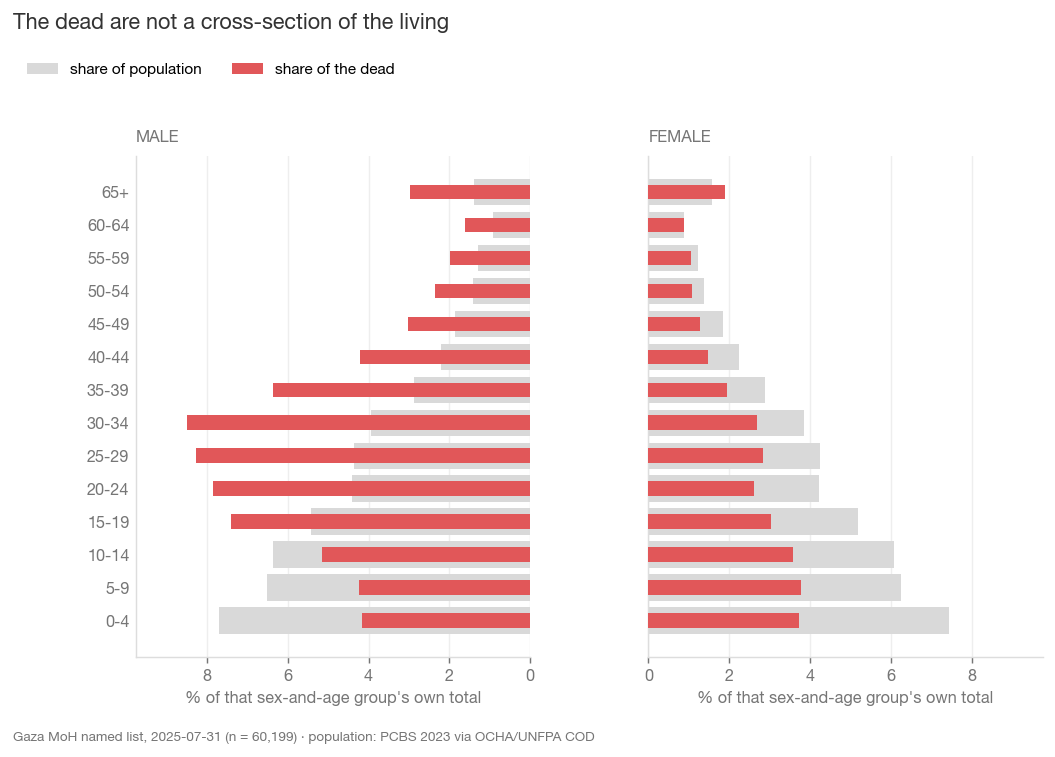

In [11]:
share = lambda v, tot: np.array(v) / tot * 100
dm, df_, pm, pf = (share(deaths_m, D), share(deaths_f, D),
                   share(pop_m, P),    share(pop_f, P))

fig, (axl, axr) = plt.subplots(1, 2, figsize=(9, 5), sharey=True,
                               gridspec_kw={"wspace": .30})
y   = np.arange(len(BANDS))
lim = max(dm.max(), df_.max(), pm.max(), pf.max()) * 1.15

for ax, pop_s, dth_s, title in ((axl, pm, dm, "MALE"), (axr, pf, df_, "FEMALE")):
    ax.barh(y, pop_s, height=.80, color=GREY_L, label="share of population", zorder=2)
    ax.barh(y, dth_s, height=.44, color=RED,    label="share of the dead",   zorder=3)
    ax.set_title(title, fontsize=9, color=MUTED, pad=8)
    ax.set_xlim(0, lim)
    ax.set_xlabel("% of that sex-and-age group's own total")
    ax.grid(axis="x", color="#EEEEEE", lw=.8, zorder=0)
    ax.set_axisbelow(True)

axl.invert_xaxis()
axl.set_yticks(y, BANDS)
axl.tick_params(axis="y", length=0)
axr.tick_params(axis="y", length=0, labelleft=False)
fig.suptitle("The dead are not a cross-section of the living",
             x=.02, y=1.10, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.legend(*axl.get_legend_handles_labels(), loc="upper left",
           bbox_to_anchor=(.02, 1.045), ncols=2)
fig.text(.02, -.02, f"Gaza MoH named list, {LIST_DATE} (n = {D:,}) · "
                    "population: PCBS 2023 via OCHA/UNFPA COD",
         fontsize=7.5, color=MUTED)
plt.show()

The two panels tell different stories, which is the point. The female panel is close to the
shape of the population — grey and red roughly track. The male panel is not: the red bars
collapse below grey through childhood and then overshoot it hard from 15 through 44.

## 7. Expected against actual

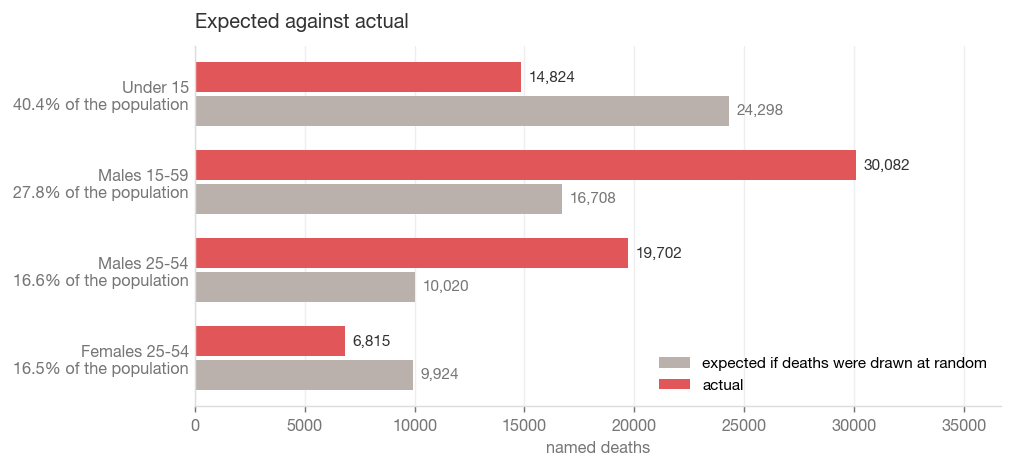

Under 15         14,824 actual vs  24,298 expected  =  0.61×
Males 15-59      30,082 actual vs  16,708 expected  =  1.80×
Males 25-54      19,702 actual vs  10,020 expected  =  1.97×
Females 25-54     6,815 actual vs   9,924 expected  =  0.69×


In [12]:
groups = [group(0, 2, None, "Under 15"),
          group(3, 11, "m", "Males 15-59"),
          group(5, 10, "m", "Males 25-54"),
          group(5, 10, "f", "Females 25-54")]

fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(groups))
ax.barh(y + .19, [g["expected if random"] for g in groups], height=.34,
        color=GREY, label="expected if deaths were drawn at random")
ax.barh(y - .19, [g["actual deaths"] for g in groups], height=.34,
        color=RED, label="actual")

for i, g in enumerate(groups):                       # direct labels: the grey needs them
    ax.text(g["expected if random"] + D * .006, i + .19, f'{g["expected if random"]:,.0f}',
            va="center", fontsize=8.5, color=MUTED)
    ax.text(g["actual deaths"] + D * .006, i - .19, f'{g["actual deaths"]:,.0f}',
            va="center", fontsize=8.5, color=INK, fontweight="bold")

ax.set_yticks(y, [f'{g["group"]}\n{g["pop %"]:.1f}% of the population' for g in groups])
ax.tick_params(axis="y", length=0)
ax.invert_yaxis()
ax.set_xlim(0, max(max(g["expected if random"], g["actual deaths"]) for g in groups) * 1.22)
ax.set_xlabel("named deaths")
ax.grid(axis="x", color="#EEEEEE", lw=.8)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
ax.set_title("Expected against actual", pad=10)
plt.show()

for g in groups:
    print(f'{g["group"]:16s} {g["actual deaths"]:6,.0f} actual vs {g["expected if random"]:7,.0f} '
          f'expected  =  {g["actual ÷ expected"]:.2f}×')

## 8. The sex ratio

This is the cleanest test in the notebook, because it needs almost nothing from the
denominator. A boy and a girl of the same age in Gaza live in the same building and shelter in
the same room. A collapsing structure does not sort them. So under indiscriminate killing the
male-to-female death ratio should be flat across age, sitting wherever the population's own sex
ratio sits — which in Gaza is about 1.03, and never leaves 0.88–1.06 in any band.

Any climb with age has to come from something that distinguishes men from women — and the only
thing that does that in a war is who is fighting it.

,male deaths,female deaths,M:F deaths,M:F population
0-4,2503,2241,1.12,1.037
5-9,2545,2277,1.12,1.044
10-14,3104,2154,1.44,1.045
15-19,4453,1832,2.43,1.045
20-24,4730,1579,3.00,1.045
25-29,4984,1704,2.92,1.027
30-34,5109,1619,3.16,1.018
35-39,3833,1170,3.28,0.997
40-44,2529,890,2.84,0.983
45-49,1824,775,2.35,1.002


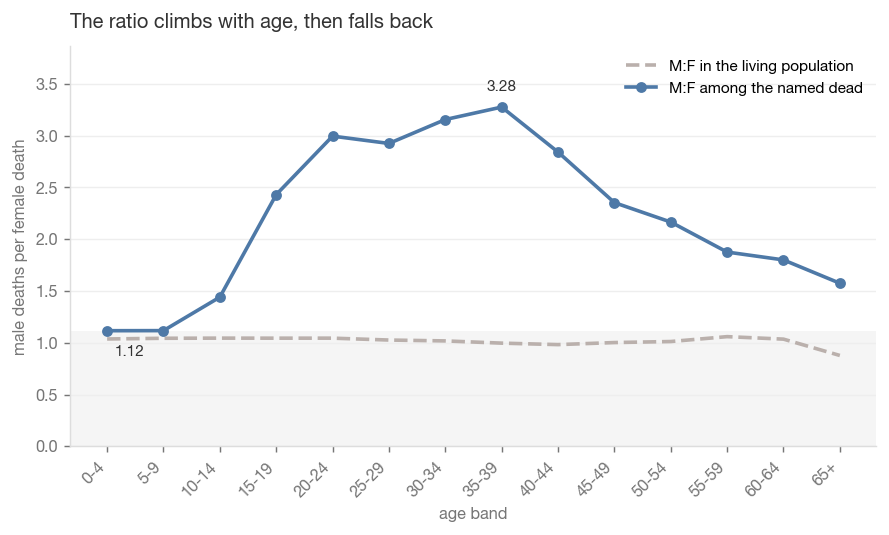

0-4:    1.12 male deaths per female death (population: 1.04)
peak:   3.28 at 35-39
65+:    1.58
whole list: 2.13


In [13]:
ratio     = np.array([m_ / f_ if f_ else np.nan for m_, f_ in zip(deaths_m, deaths_f)])
pop_ratio = np.array(pop_m) / np.array(pop_f)

sex_tbl = pd.DataFrame({"male deaths": deaths_m, "female deaths": deaths_f,
                        "M:F deaths": ratio.round(2),
                        "M:F population": pop_ratio.round(3)}, index=BANDS)
display(sex_tbl)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(BANDS))
ax.plot(x, pop_ratio, color=GREY, lw=2, ls="--", zorder=2,
        label="M:F in the living population")
ax.plot(x, ratio, color=BLUE, lw=2, marker="o", ms=5, zorder=3,
        label="M:F among the named dead")
ax.axhspan(0, 1.10, color="#F5F5F5", zorder=0)

peak = int(np.nanargmax(ratio))
ax.annotate(f"{ratio[peak]:.2f}", (peak, ratio[peak]), textcoords="offset points",
            xytext=(0, 9), ha="center", fontsize=8.5, fontweight="bold", color=INK)
ax.annotate(f"{ratio[0]:.2f}", (0, ratio[0]), textcoords="offset points",
            xytext=(4, -14), fontsize=8.5, color=INK)

ax.set_xticks(x, BANDS, rotation=45, ha="right")
ax.set_ylim(0, max(np.nanmax(ratio) * 1.18, 3.6))
ax.set_ylabel("male deaths per female death")
ax.set_xlabel("age band")
ax.grid(axis="y", color="#EEEEEE", lw=.8)
ax.set_axisbelow(True)
ax.legend(loc="upper right")
ax.set_title("The ratio climbs with age, then falls back", pad=10)
plt.show()

print(f"0-4:    {ratio[0]:.2f} male deaths per female death "
      f"(population: {pop_ratio[0]:.2f})")
print(f"peak:   {ratio[peak]:.2f} at {BANDS[peak]}")
print(f"65+:    {ratio[-1]:.2f}")
print(f"whole list: {sum(deaths_m)/sum(deaths_f):.2f}")

Among the under-fives the ratio is **1.12** — essentially the population's own ratio, which is
what indiscriminate death looks like. It stays there through age nine, breaks upward at ten,
reaches **2.43** by 15–19 and peaks at **3.28** in the 35–39 band, then falls back toward the
population ratio in old age.

The shape is the finding. A hazard that ignored people would give a flat line. This line is
flat exactly where combatants do not exist — small children and the elderly — and rises exactly
across the ages at which they do.

Two things this does *not* establish, and the essay should not be read as claiming:

1. **It does not make every military-age man a combatant.** The excess is a group-level
   pattern; it says nothing about any individual, and men in this age range also die as
   civilians in ways women do not (they are likelier to be outdoors, working, moving between
   shelters, or digging at rubble).
2. **It does not measure the total number of dead.** It measures the *composition* of the
   Ministry's own named list. If the list under-records some group, the composition is biased
   by exactly that. Everything here is conditional on the list the Ministry chose to publish.

## 9. Does the pattern hold across all nine lists?

One list could be an artefact of one release. Nine lists over nineteen months, each a separate
publication, cannot all be the same artefact.

In [14]:
trend = []
for date, c in clean_lists:
    trend.append({
        "list": date, "usable": len(c),
        "% female":        (c.sex == "f").mean() * 100,
        "% under 15":      (c.age < 15).mean() * 100,
        "% males 15-59":   ((c.sex == "m") & c.age.between(15, 59)).mean() * 100,
        "M:F ratio":       (c.sex == "m").sum() / (c.sex == "f").sum(),
    })
trend = pd.DataFrame(trend).set_index("list")
display(trend.round(2))

,usable,% female,% under 15,% males 15-59,M:F ratio
list,,,,,
2024-01-05,13143,43.19,31.66,36.54,1.32
2024-03-29,20042,39.73,26.31,42.28,1.52
2024-04-30,24240,37.36,24.88,44.72,1.68
2024-06-30,28173,36.96,27.32,43.14,1.71
2024-08-31,34306,36.00,26.81,44.10,1.78
2025-03-23,50020,32.99,25.32,48.46,2.03
2025-06-15,55202,32.73,25.14,48.91,2.06
2025-07-15,58380,32.08,24.71,49.76,2.12
2025-07-31,60199,31.91,24.62,49.97,2.13


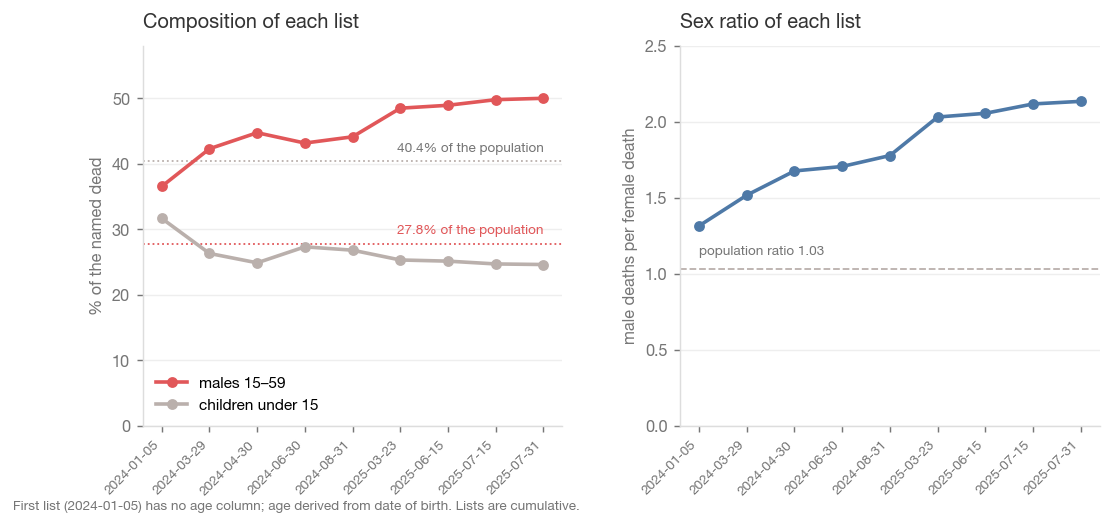

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.8), gridspec_kw={"wspace": .28})
x = np.arange(len(trend))

a1.plot(x, trend["% males 15-59"], color=RED,  lw=2, marker="o", ms=5, label="males 15–59")
a1.plot(x, trend["% under 15"],    color=GREY, lw=2, marker="o", ms=5, label="children under 15")
a1.axhline(27.8, color=RED,  lw=1, ls=":", zorder=1)
a1.axhline(40.4, color=GREY, lw=1, ls=":", zorder=1)
a1.text(len(trend) - 1, 29.4, "27.8% of the population", ha="right", fontsize=7.5, color=RED)
a1.text(len(trend) - 1, 41.9, "40.4% of the population", ha="right", fontsize=7.5, color=MUTED)
a1.set_ylim(0, 58)
a1.set_ylabel("% of the named dead")
a1.legend(loc="lower left")
a1.set_title("Composition of each list", pad=10)

a2.plot(x, trend["M:F ratio"], color=BLUE, lw=2, marker="o", ms=5)
a2.axhline(1.03, color=GREY, lw=1, ls="--")
a2.text(0, 1.13, "population ratio 1.03", fontsize=7.5, color=MUTED)
a2.set_ylim(0, 2.5)
a2.set_ylabel("male deaths per female death")
a2.set_title("Sex ratio of each list", pad=10)

for ax in (a1, a2):
    ax.set_xticks(x, trend.index, rotation=45, ha="right", fontsize=7.5)
    ax.grid(axis="y", color="#EEEEEE", lw=.8)
    ax.set_axisbelow(True)

fig.text(.02, -.06, "First list (2024-01-05) has no age column; age derived from date of birth. "
                    "Lists are cumulative.", fontsize=7.5, color=MUTED)
plt.show()

Every list is skewed the same way, and the skew *grows monotonically*: males 15–59 rise from
36.5% of the January 2024 list to 50.0% of the July 2025 list, and the overall sex ratio rises
from 1.32 to 2.13.

But these lists are cumulative — each one contains the previous one — so a rising cumulative
share is a weak statement. The sharper question is what the *newly added* names look like in
each release. Matching on national ID gives that directly.

In [16]:
batches = []
for (d0, a), (d1, b) in zip(clean_lists, clean_lists[1:]):
    new = b[~b["id"].isin(set(a["id"]))]
    if not len(new):
        continue
    batches.append({"names added in": f"{d0} → {d1}", "n": len(new),
                    "% female":      (new.sex == "f").mean() * 100,
                    "% under 15":    (new.age < 15).mean() * 100,
                    "% males 15-59": ((new.sex == "m") & new.age.between(15, 59)).mean() * 100,
                    "M:F ratio":     (new.sex == "m").sum() / (new.sex == "f").sum()})
batches = pd.DataFrame(batches).set_index("names added in")
display(batches.round(2))

print(f'every batch M:F between {batches["M:F ratio"].min():.2f} and '
      f'{batches["M:F ratio"].max():.2f}; population ratio is 1.03')

,n,% female,% under 15,% males 15-59,M:F ratio
names added in,,,,,
2024-01-05 → 2024-03-29,7039,33.04,18.82,52.14,2.03
2024-03-29 → 2024-04-30,4377,26.37,18.14,56.18,2.79
2024-04-30 → 2024-06-30,7523,33.64,24.92,45.42,1.97
2024-06-30 → 2024-08-31,6658,31.86,24.89,48.23,2.14
2024-08-31 → 2025-03-23,18666,28.21,22.40,54.86,2.55
2025-03-23 → 2025-06-15,5244,30.19,23.61,53.03,2.31
2025-06-15 → 2025-07-15,3195,21.00,17.31,64.54,3.76
2025-07-15 → 2025-07-31,1826,26.29,21.85,56.52,2.80


every batch M:F between 1.97 and 3.76; population ratio is 1.03


Eight independent increments, published months apart, and **not one of them** looks like the
population it was drawn from. The incremental male-to-female ratio never drops below 1.99 and
reaches 3.76 in the batch added during June–July 2025. The cumulative skew is not an artefact
of one bad release; it is present in every release.

## 10. What the notebook establishes, and what it does not

**Establishes**, from the Ministry's own published records:

- The named dead are not a random draw from Gaza's population; the deviation is enormous and
  it is the same shape in all nine lists and in all eight incremental batches.
- The deviation runs in a specific direction: military-age males are recorded at roughly twice
  their population share, children at about six-tenths of theirs.
- The male-to-female death ratio is flat at the population ratio in the age bands where
  combatants do not exist and rises threefold across the bands where they do.

**Does not establish:**

- Any individual's status. Group composition is not evidence about a person.
- The total number of dead, or the true civilian-to-combatant split. This is the composition
  of a list, and only of a list.
- That the list is complete or unbiased. If the Ministry's recording process itself
  under-captures women and children — plausible in a collapsed health system — part of the
  skew is a recording artefact rather than a fact about who died. Nothing in the data can
  separate those two, and the honest statement is that the composition is what it is.

## 11. Export the counts to the site

The essay's charts read these numbers from `assets/gaza-data.js`. Writing that file from this
notebook is the point of the whole exercise — the published charts and this analysis cannot
drift apart, because one generates the other.

In [17]:
def js_arr(v):
    return "[" + ", ".join(str(x).rjust(6) for x in v) + "]"

HEAD = [
    "/* ------------------------------------------------------------------",
    "   gaza-data.js - counts behind the casualty-demography essay.",
    "",
    "   GENERATED FILE. Do not hand-edit.",
    "   Produced by analysis/gaza-casualty-demographics.ipynb; re-run that",
    "   notebook to regenerate. Every number below is a count, not an",
    "   estimate: `deaths` tallies named records in ONE published Gaza MoH",
    "   list, `pop` is a published PCBS population figure. The age bands of",
    "   the two match exactly, which is what makes the shares comparable.",
    "   ------------------------------------------------------------------ */",
    "",
    "const GAZA = {",
    "  loaded: true,",
    "",
    f"  source:    'Gaza MoH named list, {LIST_DATE}, n = {D:,}',",
    "  popSource: 'PCBS Gaza Strip, 2023, via OCHA/UNFPA COD cod-ps-pse',",
    f'  excluded:  {quality[-1]["excluded"]},    // records dropped for missing/unparseable age or sex',
    "",
    "  bands: ['" + "', '".join(BANDS[:7]) + "',",
    "          '" + "', '".join(BANDS[7:]) + "'],",
    "",
    "  deaths: {",
    f"    m: {js_arr(deaths_m)},",
    f"    f: {js_arr(deaths_f)}",
    "  },",
    "  pop: {",
    f"    m: {js_arr(pop_m)},",
    f"    f: {js_arr(pop_f)}",
    "  }",
    "};",
    "",
]
js = "\n".join(HEAD)

# keep the derived helpers already in the file; only the counts are regenerated
tail = OUT_JS.read_text().split("/* --- derived,")[1]
OUT_JS.write_text(js + "/* --- derived," + tail)

print(f"wrote {rel(OUT_JS)}  ({OUT_JS.stat().st_size:,} bytes)\n")
print(js[js.index("const GAZA"):])

wrote assets/gaza-data.js  (3,571 bytes)

const GAZA = {
  loaded: true,

  source:    'Gaza MoH named list, 2025-07-31, n = 60,199',
  popSource: 'PCBS Gaza Strip, 2023, via OCHA/UNFPA COD cod-ps-pse',
  excluded:  0,    // records dropped for missing/unparseable age or sex

  bands: ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34',
          '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65+'],

  deaths: {
    m: [  2503,   2545,   3104,   4453,   4730,   4984,   5109,   3833,   2529,   1824,   1423,   1197,    965,   1791],
    f: [  2241,   2277,   2154,   1832,   1579,   1704,   1619,   1170,    890,    775,    657,    638,    536,   1137]
  },
  pop: {
    m: [171595, 145276, 141660, 120553,  98073,  97192,  87562,  64156,  49109,  41317,  31260,  28753,  20588,  30832],
    f: [165462, 139182, 135532, 115384,  93854,  94657,  85986,  64356,  49977,  41214,  30876,  27135,  19882,  35121]
  }
};



In [18]:
# Final self-check: the published file must reproduce the headline numbers.
txt = OUT_JS.read_text()
assert "loaded: true" in txt
assert f"n = {D:,}" in txt
print(f"total named dead in exported file : {sum(deaths_m) + sum(deaths_f):,}")
print(f"total population in exported file : {sum(pop_m) + sum(pop_f):,}")
print(f"children under 15, actual         : {sum(deaths_m[:3]) + sum(deaths_f[:3]):,}")
print(f"children under 15, if random      : {comp['expected if random'][:3].sum():,.0f}")
print(f"males 15-59, share of the dead    : {group(3,11,'m')['deaths %']:.1f}%")
print(f"males 15-59, share of Gaza        : {group(3,11,'m')['pop %']:.1f}%")

total named dead in exported file : 60,199
total population in exported file : 2,226,544
children under 15, actual         : 14,824
children under 15, if random      : 24,298
males 15-59, share of the dead    : 50.0%
males 15-59, share of Gaza        : 27.8%
